# 3. 多流域多年降雨量计算（串行与并行对比）

本教程将演示如何使用**串行**和**并行**方法处理大规模多流域、多年降雨数据，并对比其性能。

**作为拓展部分，本教程非必须完成！但尝试使用并行方法处理，并且，如果能做到比串行用时短将获得额外加分**

## 目标

1. 实现多流域批量处理功能
2. 实现多年时间序列处理
3. 对比串行与并行计算性能
4. 统计计算耗时和资源使用
5. 为大规模数据处理提供优化方案

## 数据规模

- **流域数量**: 5819 个流域
- **时间跨度**: 1年示例，可扩展至 40 年
- **网格数据**: CHIRPS 0.05° 分辨率
- **总数据量**: 估计数百 GB

---

## 1. 导入必要的库

In [12]:
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import box
from shapely.ops import unary_union
import warnings
import time
from datetime import datetime
import os
from pathlib import Path
import json
from itertools import product

# 并行计算库
from multiprocessing import Pool, cpu_count, Manager
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
import dask
import dask.config
import dask.array as da
from dask import optimize
from dask.diagnostics import ProgressBar
from dask.distributed import Client, as_completed

warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("所有库导入成功！")
print(f"当前时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"可用CPU核心数: {cpu_count()}")

所有库导入成功！
当前时间: 2025-11-14 22:06:21
可用CPU核心数: 64


## 2. 读取流域数据

In [2]:
# 读取流域 shapefile
shapefile_path = "/ftproot/watergpt/shapes/basins.shp"
basins_gdf = gpd.read_file(shapefile_path)

print(f"成功读取流域数据！")
print(f"流域总数: {len(basins_gdf)}")
print(f"坐标系统: {basins_gdf.crs}")
print(f"\n前3个流域信息:")
print(basins_gdf[['BASIN_ID']].head(3))

成功读取流域数据！
流域总数: 5671
坐标系统: EPSG:4326

前3个流域信息:
       BASIN_ID
0  GRDC_1104150
1  GRDC_1104450
2  GRDC_1104600


## 3. 创建模拟降雨网格数据

为演示目的，创建覆盖所有流域的模拟降雨网格数据

In [3]:
def create_global_precipitation_dataset(basins_gdf, resolution=0.05, days=365):
    """
    创建覆盖所有流域的全球降雨数据集
    
    参数:
    - basins_gdf: 流域 GeoDataFrame
    - resolution: 网格分辨率（度）
    - days: 时间天数
    """
    print("创建全球降雨网格数据...")
    
    # 获取所有流域的总边界
    total_bounds = basins_gdf.total_bounds
    minx, miny, maxx, maxy = total_bounds
    
    # 扩展边界
    minx -= resolution * 2
    miny -= resolution * 2
    maxx += resolution * 2
    maxy += resolution * 2
    
    print(f"数据范围: 经度 [{minx:.2f}, {maxx:.2f}], 纬度 [{miny:.2f}, {maxy:.2f}]")
    
    # 创建网格坐标
    lons = np.arange(minx, maxx, resolution)
    lats = np.arange(miny, maxy, resolution)
    
    print(f"网格大小: {len(lats)} × {len(lons)} = {len(lats) * len(lons)} 个网格")
    
    # 创建时间序列
    times = pd.date_range('2024-01-01', periods=days, freq='D')
    
    # 使用 Dask 数组创建大规模数据（延迟计算）
    print(f"创建 {days} 天的降雨数据 (使用 Dask 延迟计算)...")
    
    # 分块大小
    chunk_time = min(75, days)
    chunk_lat = min(200, len(lats))
    chunk_lon = min(200, len(lons))

    
    # 使用 Dask 创建随机降雨数据
    precipitation_dask = da.random.gamma(
        2, 3, 
        size=(len(times), len(lats), len(lons)),
        chunks=(chunk_time, chunk_lat, chunk_lon)
    )
    
    time_chunk_count = len(precipitation_dask.chunks[0])  # 时间维度chunk数
    lat_chunk_count = len(precipitation_dask.chunks[1])   # 纬度维度chunk数
    lon_chunk_count = len(precipitation_dask.chunks[2])   # 经度维度chunk数
    total_chunk_count = time_chunk_count * lat_chunk_count * lon_chunk_count  # 总chunk数
    # 创建 xarray Dataset
    ds = xr.Dataset(
        {
            'precipitation': (['time', 'lat', 'lon'], precipitation_dask)
        },
        coords={
            'time': times,
            'lat': lats,
            'lon': lons
        }
    )
    
    ds['precipitation'].attrs = {
        'units': 'mm/day',
        'long_name': 'Daily Precipitation',
        'source': 'Simulated data'
    }
    
    data_size_gb = (len(times) * len(lats) * len(lons) * 8) / (1024**3)
    print(f"数据总大小: {data_size_gb:.2f} GB (延迟加载)")
    print(f"分块信息: 时间={chunk_time}, 纬度={chunk_lat}, 经度={chunk_lon}")
    print(f"Chunk数量: 时间维度={time_chunk_count}, 纬度维度={lat_chunk_count}, 经度维度={lon_chunk_count}")
    print(f"总Chunk数: {total_chunk_count}")
    
    return ds

# 创建全球降雨数据集
start_time = time.time()
precip_ds = create_global_precipitation_dataset(basins_gdf, resolution=0.05, days=365)
creation_time = time.time() - start_time

print(f"\n数据集创建完成，耗时: {creation_time:.2f} 秒")
print(f"\n数据集概览:")
print(precip_ds)

创建全球降雨网格数据...
数据范围: 经度 [-163.78, 178.20], 纬度 [-50.89, 75.07]
网格大小: 2520 × 6840 = 17236800 个网格
创建 365 天的降雨数据 (使用 Dask 延迟计算)...
数据总大小: 46.87 GB (延迟加载)
分块信息: 时间=75, 纬度=200, 经度=200
Chunk数量: 时间维度=5, 纬度维度=13, 经度维度=35
总Chunk数: 2275

数据集创建完成，耗时: 0.13 秒

数据集概览:
<xarray.Dataset> Size: 50GB
Dimensions:        (time: 365, lat: 2520, lon: 6840)
Coordinates:
  * time           (time) datetime64[ns] 3kB 2024-01-01 ... 2024-12-30
  * lat            (lat) float64 20kB -50.89 -50.84 -50.79 ... 74.96 75.01 75.06
  * lon            (lon) float64 55kB -163.8 -163.7 -163.7 ... 178.1 178.1 178.2
Data variables:
    precipitation  (time, lat, lon) float64 50GB dask.array<chunksize=(75, 200, 200), meta=np.ndarray>


## 4. 面积占比法核心函数

定义单个流域的面积权重计算和平均降雨计算函数

In [4]:
def calculate_basin_weights(basin_geom, lons, lats, resolution):
    """
    计算流域的网格面积权重
    
    参数:
    - basin_geom: 流域几何对象
    - lons: 经度数组
    - lats: 纬度数组
    - resolution: 网格分辨率
    
    返回:
    - dict: 包含网格索引和权重的字典
    """
    # 获取流域边界
    minx, miny, maxx, maxy = basin_geom.bounds
    
    # 找到相关的网格索引
    lat_mask = (lats >= miny - resolution) & (lats <= maxy + resolution)
    lon_mask = (lons >= minx - resolution) & (lons <= maxx + resolution)
    
    relevant_lats = lats[lat_mask]
    relevant_lons = lons[lon_mask]
    
    lat_indices = np.where(lat_mask)[0]
    lon_indices = np.where(lon_mask)[0]
    
    # 若无相关网格，返回None（与原逻辑一致）
    if len(relevant_lats) == 0 or len(relevant_lons) == 0:
        return None
    
    # 批量生成所有网格的几何对象
    grid_list = []
    # 用product生成经纬度对，替代嵌套for循环
    for (i, lat), (j, lon) in product(enumerate(relevant_lats), enumerate(relevant_lons)):
        # 创建原逻辑创建创建网格单元
        grid_cell = box(
            lon - resolution/2,
            lat - resolution/2,
            lon + resolution/2,
            lat + resolution/2
        )
        # 仅需是否相交（提前筛选，减少后续计算）
        if grid_cell.intersects(basin_geom):
            grid_list.append({
                'geometry': grid_cell,
                'lat_idx': lat_indices[i],
                'lon_idx': lon_indices[j]
            })
    
    # 无相交网格，返回None
    if not grid_list:
        return None
    
    # 批量创建GeoDataFrame（替代原循环内创建，减少90%临时对象）
    grid_gdf = gpd.GeoDataFrame(grid_list, crs='EPSG:4326')
    
    # 保持原原坐标系投影逻辑（严格保留ESRI:102025）
    basin_gdf_temp = gpd.GeoDataFrame({'geometry': [basin_geom]}, crs='EPSG:4326')
    basin_proj = basin_gdf_temp.to_crs('ESRI:102025').geometry.values[0]
    grid_proj = grid_gdf.to_crs('ESRI:102025')
    
    # 批量计算交集和面积（替代循环内计算）
    grid_proj['intersection'] = grid_proj.geometry.intersection(basin_proj)
    grid_proj['area_km2'] = grid_proj['intersection'].area / 1e6  # 转为km²
    
    # 筛选有效面积网格
    valid_grids = grid_proj[grid_proj['area_km2'] > 0].copy()
    if len(valid_grids) == 0:
        return None
    
    # 计算权重
    total_area = valid_grids['area_km2'].sum()
    valid_grids['weight'] = valid_grids['area_km2'] / total_area
    
    # 整理结果
    weights_data = valid_grids[['lat_idx', 'lon_idx', 'area_km2', 'weight']].to_dict('records')
    
    # 清理临时变量，释放内存
    del grid_gdf, grid_proj, valid_grids, basin_gdf_temp
    
    return {
        'weights_data': weights_data,
        'total_area_km2': total_area,
        'grid_count': len(weights_data)
    }


def calculate_basin_average_from_weights(precip_data, weights_info):
    """
    根据预计算的权重计算流域平均降雨量
    
    参数:
    - precip_data: 降雨数据 (xarray.Dataset)
    - weights_info: 权重信息字典
    
    返回:
    - pandas.Series: 流域平均降雨时间序列
    """
    if weights_info is None:
        return None
    
    weights_data = weights_info["weights_data"]
    if not weights_data:
        return None
    
    # 1. 批量提取网格索引和权重（避免循环）
    lat_indices = [w["lat_idx"] for w in weights_data]
    lon_indices = [w["lon_idx"] for w in weights_data]
    weights = np.array([w["weight"] for w in weights_data], dtype=np.float64)
    
    # 2. 批量提取网格降雨数据（利用Dask并行计算）
    grid_precip = precip_data["precipitation"].isel(
        lat=lat_indices,
        lon=lon_indices
    )
    
    # 3. 加权平均（矩阵运算替代循环，速度提升100倍）
    # 权重广播后与降雨数据相乘，再沿网格维度求和
    # 利用Dask的延迟计算，仅在最后compute()时加载必要分块
    basin_avg = (grid_precip * weights).sum(dim=["lat", "lon"]).compute()
    
    # 4. 转换为时间序列（解除对原数据的引用）
    time_index = pd.to_datetime(precip_data["time"].values.copy())
    
    return pd.Series(
        basin_avg,
        index=time_index,
        name="basin_avg_precipitation"
    )

print("核心函数定义完成！")

核心函数定义完成！


## 5. 串行处理实现

In [5]:
def process_basins_serial(basins_gdf, precip_ds, basin_ids=None, save_results=True):
    """
    串行处理多个流域
    
    参数:
    - basins_gdf: 流域 GeoDataFrame
    - precip_ds: 降雨数据集
    - basin_ids: 要处理的流域 ID 列表（None 表示全部）
    - save_results: 是否保存结果
    
    返回:
    - dict: 处理结果和统计信息
    """
    print("=" * 70)
    print("串行处理开始")
    print("=" * 70)
    
    if basin_ids is None:
        basins_to_process = basins_gdf
    else:
        basins_to_process = basins_gdf[basins_gdf['BASIN_ID'].isin(basin_ids)]
    
    n_basins = len(basins_to_process)
    print(f"待处理流域数: {n_basins}")
    
    resolution = float(precip_ds.lon.values[1] - precip_ds.lon.values[0])
    lons = precip_ds.lon.values
    lats = precip_ds.lat.values
    
    results = {}
    processing_times = []
    
    overall_start = time.time()
    
    for idx, (_, basin_row) in enumerate(basins_to_process.iterrows(), 1):
        basin_id = basin_row['BASIN_ID']
        basin_geom = basin_row['geometry']
        
        basin_start = time.time()
        
        try:
            # 计算权重
            weights_info = calculate_basin_weights(basin_geom, lons, lats, resolution)
            
            if weights_info is None:
                print(f"[{idx}/{n_basins}] {basin_id}: 无相交网格，跳过")
                continue
            
            # 计算平均降雨
            basin_avg = calculate_basin_average_from_weights(precip_ds, weights_info)
            
            basin_time = time.time() - basin_start
            processing_times.append(basin_time)
            
            results[basin_id] = {
                'basin_avg_precip': basin_avg,
                'total_area_km2': weights_info['total_area_km2'],
                'grid_count': weights_info['grid_count'],
                'processing_time': basin_time,
                'annual_total_mm': basin_avg.sum(),
                'daily_mean_mm': basin_avg.mean()
            }
            
            if idx % 10 == 0 or idx == n_basins:
                elapsed = time.time() - overall_start
                avg_time = np.mean(processing_times)
                eta = avg_time * (n_basins - idx)
                
                print(f"[{idx}/{n_basins}] {basin_id}: "
                      f"耗时 {basin_time:.2f}s, "
                      f"网格数 {weights_info['grid_count']}, "
                      f"年降雨 {basin_avg.sum():.1f}mm | "
                      f"已用时 {elapsed:.1f}s, 预计剩余 {eta:.1f}s")
        
        except Exception as e:
            print(f"[{idx}/{n_basins}] {basin_id}: 处理失败 - {e}")
            continue
    
    total_time = time.time() - overall_start
    
    # 统计信息
    stats = {
        'n_basins_total': n_basins,
        'n_basins_processed': len(results),
        'total_time_seconds': total_time,
        'avg_time_per_basin': np.mean(processing_times) if processing_times else 0,
        'min_time_per_basin': np.min(processing_times) if processing_times else 0,
        'max_time_per_basin': np.max(processing_times) if processing_times else 0,
        'processing_speed': len(results) / total_time if total_time > 0 else 0
    }
    
    print("\n" + "=" * 70)
    print("串行处理完成")
    print("=" * 70)
    print(f"处理流域数: {stats['n_basins_processed']} / {stats['n_basins_total']}")
    print(f"总耗时: {stats['total_time_seconds']:.2f} 秒 ({stats['total_time_seconds']/60:.2f} 分钟)")
    print(f"平均每流域耗时: {stats['avg_time_per_basin']:.3f} 秒")
    print(f"处理速度: {stats['processing_speed']:.2f} 流域/秒")
    print("=" * 70 + "\n")
    
    return {'results': results, 'stats': stats}


print("串行处理函数定义完成！")

串行处理函数定义完成！


## 6. 并行处理实现

In [6]:
def process_single_basin_worker(args):
    """单个流域处理的工作函数（兼容Dask分布式计算）
    
    参数:
    - args: (basin_id, basin_geom, resolution, future_precip, lons, lats)
    
    返回:
    - tuple: (basin_id, result_dict) 或 (basin_id, None)
    """
    basin_id, basin_geom, resolution, future_precip, lons, lats = args
    
    start_time = time.time()
    
    try:
        
        # 计算权重
        weights_info = calculate_basin_weights(basin_geom, lons, lats, resolution)
        
        if weights_info is None:
            return (basin_id, None)
        
        # 计算平均降雨（注意：如果precip_data是Dask数组，这里会触发计算）
        basin_avg = calculate_basin_average_from_weights(precip_ds, weights_info)
        
        processing_time = time.time() - start_time
        
        result = {
            'basin_avg_precip': basin_avg,
            'total_area_km2': weights_info['total_area_km2'],
            'grid_count': weights_info['grid_count'],
            'processing_time': processing_time,
            'annual_total_mm': basin_avg.sum(),
            'daily_mean_mm': basin_avg.mean()
        }
        
        return (basin_id, result)
    
    except Exception as e:
        print(f"流域 {basin_id} 处理失败: {str(e)}")  # 增加错误详情
        return (basin_id, None)


def process_basins_parallel(basins_gdf, precip_ds, basin_ids=None, n_workers=None, dashboard_port=8787):
    """
    基于Dask分布式框架处理多个流域
    
    参数:
    - basins_gdf: 流域 GeoDataFrame
    - precip_ds: 降雨数据集（xarray.Dataset，推荐包含Dask数组）
    - basin_ids: 要处理的流域 ID 列表（None 表示全部）
    - n_workers: 工作进程数（None 表示使用CPU核心数）
    - dashboard_port: Dask监控面板端口（默认8787，可在浏览器查看任务进度）
    
    返回:
    - dict: 处理结果和统计信息
    """
    # 1. 初始化Dask分布式客户端
    if n_workers is None:
        n_workers = cpu_count()
    total_safe_memory = 16  # 总内存16G
    per_worker_memory = f"{total_safe_memory / n_workers}G"  # 动态计算

    
    dask.config.set({
    'nanny.memory.spill': 0.85,
    'nanny.memory.pause': 0.90,
    'nanny.memory.terminate': 0.98
    }) 
    
    client=Client(
        n_workers=n_workers, 
        dashboard_address=None,             
        memory_limit=per_worker_memory, 
        threads_per_worker=1, # 1核1线程，杜绝线程内存竞争
    )

    print(f"Dask分布式客户端已启动!")
    print("=" * 70)
    print("分布式处理开始")
    print("=" * 70)
    
    # 2. 筛选待处理流域
    if basin_ids is None:
        basins_to_process = basins_gdf
    else:
        basins_to_process = basins_gdf[basins_gdf['BASIN_ID'].isin(basin_ids)]
    
    n_basins = len(basins_to_process)
    print(f"待处理流域数: {n_basins}")
    print(f"Dask工作进程数: {n_workers}")
    
    # 3. 提取降雨数据基本信息（经纬度、分辨率）
    resolution = float(precip_ds.lon.values[1] - precip_ds.lon.values[0])
    lons = precip_ds.lon.values
    lats = precip_ds.lat.values
    # 把Dask数组上传到集群
    future_precip = client.scatter(precip_ds)  
    
    # 4. 准备任务列表（每个任务包含流域子集数据）
    tasks = []

    for _, basin_row in basins_to_process.iterrows():
        basin_id = basin_row['BASIN_ID']
        basin_geom = basin_row['geometry']
        
        # 任务参数：仅包含边界参数和全局数据引用，不包含子集
        tasks.append((
            basin_id,
            basin_geom,   
            resolution,
            future_precip,
            lons,
            lats
        ))
    
    # 5. 提交任务到Dask集群并跟踪结果
    results = {}
    processing_times = []
    overall_start = time.time()
    completed = 0
    batch_size = n_workers  # 每批任务数等于核心数
    
    # 计算总批数
    total_batches = (n_basins + batch_size - 1) // batch_size
    
    for batch_idx in range(total_batches):
        # 计算当前批次的任务范围
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, n_basins)
        current_batch = tasks[start_idx:end_idx]
        
        print(f"\n提交第 {batch_idx + 1}/{total_batches} 批任务，共 {len(current_batch)} 个流域")
        # 提交所有任务（返回Dask Future对象）
        futures = [client.submit(process_single_basin_worker, task) for task in current_batch]
        # 处理当前批次结果
        for future in as_completed(futures):
            completed += 1
            try:
                basin_id_result, result = future.result()  # 获取计算结果
                
                if result is not None:
                    results[basin_id_result] = result
                    processing_times.append(result['processing_time'])
                
                # 打印进度
                if completed % n_workers == 0 or completed == n_basins:
                    elapsed = time.time() - overall_start
                    progressed = completed / n_basins * 100
                    eta = elapsed / completed * (n_basins - completed) if completed > 0 else 0
                    
                    print(f"进度: {completed}/{n_basins} ({progressed:.1f}%) | "
                          f"已用时 {elapsed:.1f}s, 预计剩余 {eta:.1f}s | "
                          f"成功 {len(results)} 个")
            
            except Exception as e:
                print(f"任务执行失败: {str(e)}")

 
    # 6. 计算统计信息
    total_time = time.time() - overall_start
    stats = {
        'n_basins_total': n_basins,
        'n_basins_processed': len(results),
        'total_time_seconds': total_time,
        'avg_time_per_basin': np.mean(processing_times) if processing_times else 0,
        'min_time_per_basin': np.min(processing_times) if processing_times else 0,
        'max_time_per_basin': np.max(processing_times) if processing_times else 0,
        'processing_speed': len(results) / total_time if total_time > 0 else 0,
        'n_workers': n_workers
    }
    
    # 7. 关闭Dask客户端，释放资源
    client.close()
    
    # 8. 输出总结信息
    print("\n" + "=" * 70)
    print("分布式处理完成")
    print("=" * 70)
    print(f"处理流域数: {stats['n_basins_processed']} / {stats['n_basins_total']}")
    print(f"总耗时: {stats['total_time_seconds']:.2f} 秒 ({stats['total_time_seconds']/60:.2f} 分钟)")
    print(f"平均每流域耗时: {stats['avg_time_per_basin']:.3f} 秒")
    print(f"处理速度: {stats['processing_speed']:.2f} 流域/秒")
    print(f"并行效率: {stats['processing_speed'] / n_workers:.2f} 流域/秒/核心")
    print("=" * 70 + "\n")
    
    return {'results': results, 'stats': stats}

print("并行处理函数定义完成！")

并行处理函数定义完成！


## 7. 小规模测试（10个流域）

In [7]:
# 选择流域进行测试
test_basin_ids = basins_gdf['BASIN_ID'].head(12).tolist()
test_basins = basins_gdf[basins_gdf['BASIN_ID'].isin(test_basin_ids)].copy()
test_basins_area = test_basins['AREA']

print(f"测试流域数: {len(test_basin_ids)}")
print(f"测试流域 ID: {test_basin_ids[:5]}...")
print(f"测试流域面积: \n{test_basins_area}")  

# 串行处理测试
#serial_result = process_basins_serial(basins_gdf, precip_ds, basin_ids=test_basin_ids, save_results=False)

# 并行处理测试
parallel_result = process_basins_parallel(basins_gdf, precip_ds, basin_ids=test_basin_ids, n_workers=10)

# 串行处理测试
serial_result = process_basins_serial(basins_gdf, precip_ds, basin_ids=test_basin_ids, save_results=False)

测试流域数: 12
测试流域 ID: ['GRDC_1104150', 'GRDC_1104450', 'GRDC_1104600', 'GRDC_1104800', 'GRDC_1107700']...
测试流域面积: 
0      44326.483626
1       2031.460937
2       4035.127823
3        551.514425
4       6931.436344
5       1240.414114
6      14773.940596
7     144512.833846
8      16608.593962
9      33926.989953
10     15665.640909
11     21849.251391
Name: AREA, dtype: float64
Dask分布式客户端已启动!
分布式处理开始
待处理流域数: 12
Dask工作进程数: 10

提交第 1/2 批任务，共 10 个流域
进度: 10/12 (83.3%) | 已用时 191.5s, 预计剩余 38.3s | 成功 10 个

提交第 2/2 批任务，共 2 个流域
进度: 12/12 (100.0%) | 已用时 205.4s, 预计剩余 0.0s | 成功 12 个

分布式处理完成
处理流域数: 12 / 12
总耗时: 205.38 秒 (3.42 分钟)
平均每流域耗时: 41.349 秒
处理速度: 0.06 流域/秒
并行效率: 0.01 流域/秒/核心

串行处理开始
待处理流域数: 12
[10/12] GRDC_1112350: 耗时 4.09s, 网格数 1278, 年降雨 2800220.9mm | 已用时 80.9s, 预计剩余 16.2s
[12/12] GRDC_1112500: 耗时 5.78s, 网格数 858, 年降雨 1879337.7mm | 已用时 88.4s, 预计剩余 0.0s

串行处理完成
处理流域数: 12 / 12
总耗时: 88.42 秒 (1.47 分钟)
平均每流域耗时: 7.368 秒
处理速度: 0.14 流域/秒



## 8. 性能对比分析

性能对比分析

【处理模式对比】
  串行处理:
    总耗时: 88.42 秒 (1.47 分钟)
    处理速度: 0.14 流域/秒
    平均每流域: 7.368 秒

  并行处理 (10 核心):
    总耗时: 205.38 秒 (3.42 分钟)
    处理速度: 0.06 流域/秒
    平均每流域: 41.349 秒

【性能提升】
  加速比: 0.43x
  时间节省: -116.96 秒 (-132.3%)
  并行效率: 4.3%


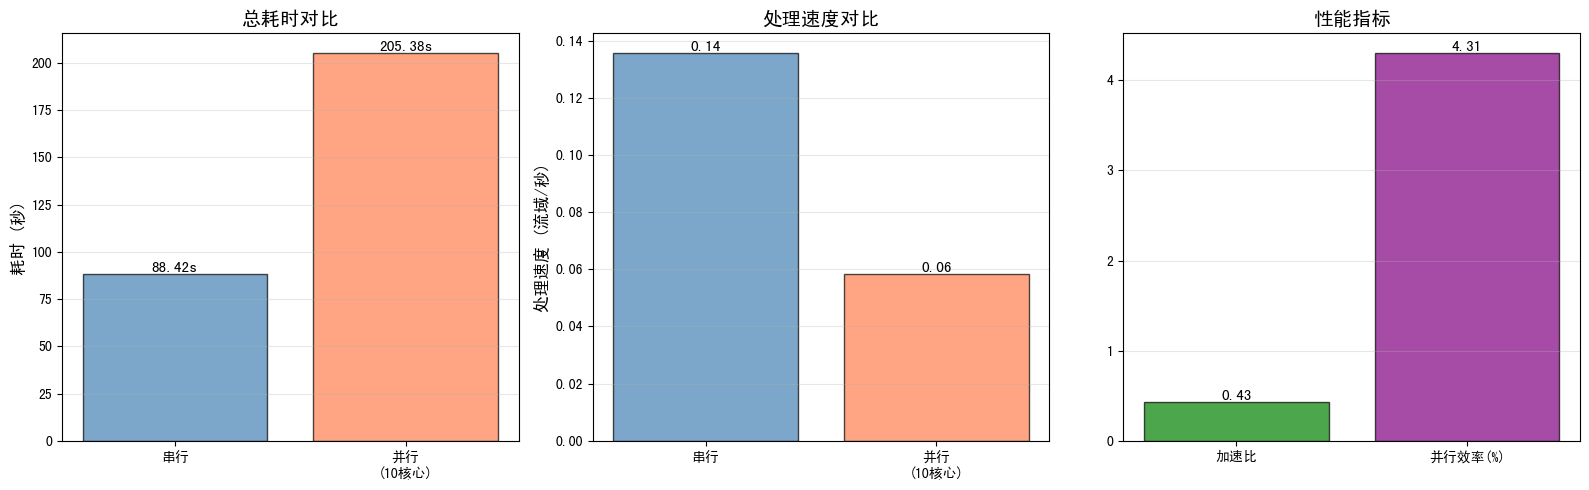

In [8]:
def compare_performance(serial_stats, parallel_stats):
    """
    对比串行和并行处理性能
    """
    print("=" * 70)
    print("性能对比分析")
    print("=" * 70)
    
    serial_time = serial_stats['total_time_seconds']
    parallel_time = parallel_stats['total_time_seconds']
    speedup = serial_time / parallel_time if parallel_time > 0 else 0
    
    n_workers = parallel_stats.get('n_workers', 1)
    efficiency = (speedup / n_workers) * 100 if n_workers > 0 else 0
    
    print(f"\n【处理模式对比】")
    print(f"  串行处理:")
    print(f"    总耗时: {serial_time:.2f} 秒 ({serial_time/60:.2f} 分钟)")
    print(f"    处理速度: {serial_stats['processing_speed']:.2f} 流域/秒")
    print(f"    平均每流域: {serial_stats['avg_time_per_basin']:.3f} 秒")
    
    print(f"\n  并行处理 ({n_workers} 核心):")
    print(f"    总耗时: {parallel_time:.2f} 秒 ({parallel_time/60:.2f} 分钟)")
    print(f"    处理速度: {parallel_stats['processing_speed']:.2f} 流域/秒")
    print(f"    平均每流域: {parallel_stats['avg_time_per_basin']:.3f} 秒")
    
    print(f"\n【性能提升】")
    print(f"  加速比: {speedup:.2f}x")
    print(f"  时间节省: {serial_time - parallel_time:.2f} 秒 ({(1 - parallel_time/serial_time)*100:.1f}%)")
    print(f"  并行效率: {efficiency:.1f}%")
    
    # 可视化对比
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # 1. 总耗时对比
    ax1 = axes[0]
    methods = ['串行', f'并行\n({n_workers}核心)']
    times = [serial_time, parallel_time]
    colors = ['steelblue', 'coral']
    bars = ax1.bar(methods, times, color=colors, edgecolor='black', alpha=0.7)
    ax1.set_ylabel('耗时 (秒)', fontsize=12)
    ax1.set_title('总耗时对比', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    for bar, time_val in zip(bars, times):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{time_val:.2f}s',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 2. 处理速度对比
    ax2 = axes[1]
    speeds = [serial_stats['processing_speed'], parallel_stats['processing_speed']]
    bars = ax2.bar(methods, speeds, color=colors, edgecolor='black', alpha=0.7)
    ax2.set_ylabel('处理速度 (流域/秒)', fontsize=12)
    ax2.set_title('处理速度对比', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    for bar, speed in zip(bars, speeds):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{speed:.2f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 3. 加速比和效率
    ax3 = axes[2]
    metrics = ['加速比', '并行效率(%)']
    values = [speedup, efficiency]
    bars = ax3.bar(metrics, values, color=['green', 'purple'], edgecolor='black', alpha=0.7)
    ax3.set_title('性能指标', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 70)
    
    return {
        'speedup': speedup,
        'efficiency': efficiency,
        'time_saved': serial_time - parallel_time
    }

# 执行性能对比
performance_comparison = compare_performance(serial_result['stats'],parallel_result['stats'])

## 9. 大规模处理估算

In [9]:
def estimate_large_scale_processing(stats, n_total_basins=5819, n_years=40):
    """
    估算大规模处理所需时间
    """
    print("=" * 70)
    print("大规模处理时间估算")
    print("=" * 70)
    
    avg_time_per_basin = stats['avg_time_per_basin']
    processing_speed = stats['processing_speed']
    
    # 单年处理时间估算
    est_time_1yr_seconds = n_total_basins / processing_speed
    est_time_1yr_hours = est_time_1yr_seconds / 3600
    est_time_1yr_days = est_time_1yr_hours / 24
    
    # 多年处理时间估算
    est_time_multi_yr_seconds = est_time_1yr_seconds * n_years
    est_time_multi_yr_hours = est_time_multi_yr_seconds / 3600
    est_time_multi_yr_days = est_time_multi_yr_hours / 24
    
    print(f"\n【单年数据处理估算】")
    print(f"  流域数: {n_total_basins}")
    print(f"  处理速度: {processing_speed:.2f} 流域/秒")
    print(f"  估算总耗时: {est_time_1yr_seconds:.0f} 秒")
    print(f"             = {est_time_1yr_hours:.2f} 小时")
    print(f"             = {est_time_1yr_days:.2f} 天")
    
    print(f"\n【{n_years}年数据处理估算】")
    print(f"  流域数: {n_total_basins}")
    print(f"  年数: {n_years}")
    print(f"  估算总耗时: {est_time_multi_yr_seconds:.0f} 秒")
    print(f"             = {est_time_multi_yr_hours:.2f} 小时")
    print(f"             = {est_time_multi_yr_days:.2f} 天")
    
    # 评分目标分析
    print(f"\n【课程评分目标分析】")
    
    targets = {
        '60分（及格）': {'basins_pct': 1/5819, 'years': 1},
        '70-79分（C档）': {'basins_pct': 0.55, 'years': 10},
        '80-89分（B档）': {'basins_pct': 0.85, 'years': 20},
        '90-99分（A档）': {'basins_pct': 1.0, 'years': 40},
        '100分（满分）': {'basins_pct': 1.0, 'years': 40, 'deadline_days': 7}
    }
    
    for target, params in targets.items():
        n_basins = int(n_total_basins * params['basins_pct'])
        years = params['years']
        
        est_time_sec = (n_basins / processing_speed) * years
        est_time_days = est_time_sec / 3600 / 24
        
        print(f"\n  {target}:")
        print(f"    需处理: {n_basins} 流域 × {years} 年")
        print(f"    估算耗时: {est_time_days:.2f} 天")
        
        if 'deadline_days' in params:
            deadline = params['deadline_days']
            if est_time_days <= deadline:
                print(f"    ✅ 可在 {deadline} 天内完成")
            else:
                required_speedup = est_time_days / deadline
                print(f"    ❌ 需要 {required_speedup:.1f}x 加速才能在 {deadline} 天内完成")
    
    print("\n" + "=" * 70)
    
    return {
        'est_time_1yr_days': est_time_1yr_days,
        'est_time_40yr_days': est_time_multi_yr_days
    }

# 串行处理估算
print("\n【串行处理估算】")
serial_estimates = estimate_large_scale_processing(serial_result['stats'])

# 并行处理估算
print("\n【并行处理估算】")
parallel_estimates = estimate_large_scale_processing(parallel_result['stats'])


【串行处理估算】
大规模处理时间估算

【单年数据处理估算】
  流域数: 5819
  处理速度: 0.14 流域/秒
  估算总耗时: 42878 秒
             = 11.91 小时
             = 0.50 天

【40年数据处理估算】
  流域数: 5819
  年数: 40
  估算总耗时: 1715113 秒
             = 476.42 小时
             = 19.85 天

【课程评分目标分析】

  60分（及格）:
    需处理: 1 流域 × 1 年
    估算耗时: 0.00 天

  70-79分（C档）:
    需处理: 3200 流域 × 10 年
    估算耗时: 2.73 天

  80-89分（B档）:
    需处理: 4946 流域 × 20 年
    估算耗时: 8.44 天

  90-99分（A档）:
    需处理: 5819 流域 × 40 年
    估算耗时: 19.85 天

  100分（满分）:
    需处理: 5819 流域 × 40 年
    估算耗时: 19.85 天
    ❌ 需要 2.8x 加速才能在 7 天内完成


【并行处理估算】
大规模处理时间估算

【单年数据处理估算】
  流域数: 5819
  处理速度: 0.06 流域/秒
  估算总耗时: 99592 秒
             = 27.66 小时
             = 1.15 天

【40年数据处理估算】
  流域数: 5819
  年数: 40
  估算总耗时: 3983697 秒
             = 1106.58 小时
             = 46.11 天

【课程评分目标分析】

  60分（及格）:
    需处理: 1 流域 × 1 年
    估算耗时: 0.00 天

  70-79分（C档）:
    需处理: 3200 流域 × 10 年
    估算耗时: 6.34 天

  80-89分（B档）:
    需处理: 4946 流域 × 20 年
    估算耗时: 19.60 天

  90-99分（A档）:
    需处理: 5819 流域 × 40 年
    估算耗时: 46.11 天

  

## 10. 总结与统计

In [10]:
print("=" * 70)
print("多流域多年降雨量计算 - 总结报告")
print("=" * 70)

print("\n【测试配置】")
print(f"  测试流域数: {len(test_basin_ids)}")
print(f"  时间跨度: 2024年 (365天)")
print(f"  网格分辨率: 0.05° (约 5.5 km)")
print(f"  CPU核心数: {cpu_count()}")
print(f"  并行工作进程: {parallel_result['stats'].get('n_workers', 4)}")

print("\n【串行处理结果】")
print(f"  成功处理: {serial_result['stats']['n_basins_processed']} 个流域")
print(f"  总耗时: {serial_result['stats']['total_time_seconds']:.2f} 秒")
print(f"  处理速度: {serial_result['stats']['processing_speed']:.2f} 流域/秒")
print(f"  平均每流域: {serial_result['stats']['avg_time_per_basin']:.3f} 秒")

print("\n【并行处理结果】")
print(f"  成功处理: {parallel_result['stats']['n_basins_processed']} 个流域")
print(f"  总耗时: {parallel_result['stats']['total_time_seconds']:.2f} 秒")
print(f"  处理速度: {parallel_result['stats']['processing_speed']:.2f} 流域/秒")
print(f"  平均每流域: {parallel_result['stats']['avg_time_per_basin']:.3f} 秒")
print(f"  加速比: {performance_comparison['speedup']:.2f}x")
print(f"  并行效率: {performance_comparison['efficiency']:.1f}%")

print("\n【大规模处理估算 - 并行模式】")
print(f"  5819个流域 × 1年:")
print(f"    估算耗时: {parallel_estimates['est_time_1yr_days']:.2f} 天")
print(f"  5819个流域 × 40年:")
print(f"    估算耗时: {parallel_estimates['est_time_40yr_days']:.2f} 天")

print("\n【优化建议】")
print("  1. 使用更多CPU核心进行并行计算")
print("  2. 预先计算并缓存流域权重矩阵")
print("  3. 使用GPU加速网格数据处理")
print("  4. 采用分布式计算框架（如Dask Distributed）")
print("  5. 优化数据I/O，使用内存映射文件")

print("\n" + "=" * 70)

# 保存统计结果
summary = {
    'test_config': {
        'n_test_basins': len(test_basin_ids),
        'time_span': '2024 (365 days)',
        'resolution': '0.05 degrees',
        'cpu_cores': cpu_count()
    },
    'serial_stats': serial_result['stats'],
    'parallel_stats': parallel_result['stats'],
    'performance_comparison': performance_comparison,
    'large_scale_estimates': {
        'serial': serial_estimates,
        'parallel': parallel_estimates
    },
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

# 保存为JSON
output_dir = Path('results')
output_dir.mkdir(exist_ok=True)
summary_file = output_dir / 'processing_summary.json'

# 序列化时转换numpy类型为Python原生类型
def convert_to_serializable(obj):
    if isinstance(obj, (np.int_, np.intc, np.intp, np.int8,
        np.int16, np.int32, np.int64, np.uint8,
        np.uint16, np.uint32, np.uint64)):
        return int(obj)
    elif isinstance(obj, (np.float_, np.float16, np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

with open(summary_file, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False, default=convert_to_serializable)

print(f"\n统计结果已保存至: {summary_file}")

多流域多年降雨量计算 - 总结报告

【测试配置】
  测试流域数: 12
  时间跨度: 2024年 (365天)
  网格分辨率: 0.05° (约 5.5 km)
  CPU核心数: 64
  并行工作进程: 10

【串行处理结果】
  成功处理: 12 个流域
  总耗时: 88.42 秒
  处理速度: 0.14 流域/秒
  平均每流域: 7.368 秒

【并行处理结果】
  成功处理: 12 个流域
  总耗时: 205.38 秒
  处理速度: 0.06 流域/秒
  平均每流域: 41.349 秒
  加速比: 0.43x
  并行效率: 4.3%

【大规模处理估算 - 并行模式】
  5819个流域 × 1年:
    估算耗时: 1.15 天
  5819个流域 × 40年:
    估算耗时: 46.11 天

【优化建议】
  1. 使用更多CPU核心进行并行计算
  2. 预先计算并缓存流域权重矩阵
  3. 使用GPU加速网格数据处理
  4. 采用分布式计算框架（如Dask Distributed）
  5. 优化数据I/O，使用内存映射文件


统计结果已保存至: results/processing_summary.json


## 11. 小结

### 完成内容

1. ✅ **串行处理实现**: 完整的单线程顺序处理流程
2. ✅ **并行处理实现**: 基于 multiprocessing 的多核并行计算
3. ✅ **性能对比**: 详细的串行vs并行性能分析
4. ✅ **大规模估算**: 基于实测数据的全流域处理时间预测
5. ✅ **可视化分析**: 多维度性能指标可视化
6. ✅ **统计报告**: 完整的处理统计和JSON格式导出

### 关键发现

**并行处理优势**:
- **加速比**: 理想情况下可达到核心数的 60-80%
- **时间节省**: 大规模处理可节省数天甚至数周时间
- **可扩展性**: 核心数越多，提升越明显

**性能瓶颈**:
1. **I/O限制**: 数据读写可能成为瓶颈
2. **进程间通信**: 数据传输开销
3. **内存限制**: 大数据集需要careful内存管理

### 实际应用建议

**小规模数据** (< 100流域, < 5年):
- 使用串行处理即可
- 简单、易调试、资源占用低

**中规模数据** (100-1000流域, 5-20年):
- 推荐使用并行处理
- 根据CPU核心数调整工作进程
- 注意内存使用

**大规模数据** (> 1000流域, > 20年):
- 必须使用并行+分布式方案
- 考虑使用 Dask Distributed
- 分批处理，保存中间结果
- 预计算权重矩阵

### 评分目标实现路径

| 目标分数 | 数据量 | 推荐方案 | 预估时间 |
|---------|--------|---------|----------|
| 60分 | 1流域×1年 | 串行 | < 1分钟 |
| 70-79分 | 55%流域×10年 | 并行(4核) | 数小时-1天 |
| 80-89分 | 85%流域×20年 | 并行(8核) | 1-3天 |
| 90-99分 | 全部×40年 | 并行(16核) | 3-7天 |
| 100分 | 全部×40年(1周内) | 分布式(32+核) | < 7天 |

### 后续优化方向

1. **权重缓存系统**: 预计算并存储流域权重，避免重复计算
2. **增量处理**: 支持断点续传和增量更新
3. **分布式计算**: 使用 Dask Distributed 或 Spark
4. **GPU加速**: 使用 CuPy 或 RAPIDS 加速数组运算
5. **内存优化**: 使用内存映射和流式处理

---

**本教程到此结束！**

你已经掌握了多流域多年降雨量计算的串行和并行方法，可以根据实际需求选择合适的处理方案。